# A PINN from scratch: the viscous Burgers equation

*My own notebook for the Scientific ML chapter — ECEN 744, Texas A&M.*

I wanted a PINN I could read end to end and run on a laptop, so I wrote this one from
scratch in **JAX**. It solves the **forward** viscous Burgers equation

$$u_t + u\,u_x - \frac{0.01}{\pi}\,u_{xx} = 0,\qquad x\in[-1,1],\ t\in[0,1],$$

with initial condition $u(0,x) = -\sin(\pi x)$ and boundaries $u(t,\pm 1)=0$. The low
viscosity $\nu = 0.01/\pi$ makes an initially smooth sine wave steepen into a **sharp
shock** near $x=0$ — the classic Burgers test.

No labeled solution goes into the interior of the domain. The only supervision is
*(1)* the PDE residual at randomly sampled **collocation points**, and *(2)* the initial
and boundary data. Everything — the residual, the optimizer — is hand-written so the
mechanics are visible. The ideas are standard course material; the code is mine.

> Runtime: about **one minute** on a CPU (15,000 Adam steps over a 3-hidden-layer
> network).


In [1]:
import time
import numpy as np
import jax
import jax.numpy as jnp
from jax import grad, vmap, jit
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", False)
print("JAX", jax.__version__, "on", jax.devices())

# --- book dataviz palette (validated categorical + chrome) ---
BLUE, YELLOW, GREEN, MAGENTA = "#2a78d6", "#eda100", "#008300", "#e87ba4"
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 11, "axes.titlesize": 12, "text.color": INK, "axes.labelcolor": INK,
    "axes.titlecolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8, "grid.color": GRID,
    "legend.frameon": False, "figure.dpi": 110,
})
KEY = jax.random.PRNGKey(0)
NU = 0.01 / jnp.pi

JAX 0.4.19 on [CpuDevice(id=0)]


## 1. The network

A small fully-connected `tanh` network $u_\theta(x,t)\to u$. I keep it deliberately tiny —
three hidden layers of 20 units — because the whole point is that this runs on a CPU.
`u_scalar` maps a **single** $(x,t)$ to a scalar so I can differentiate it cleanly; I
`vmap` it over batches later.

In [2]:
def init_params(key, layers):
    params = []
    for d_in, d_out in zip(layers[:-1], layers[1:]):
        key, k = jax.random.split(key)
        glorot = np.sqrt(2.0 / (d_in + d_out))          # Glorot/Xavier scale
        W = jax.random.normal(k, (d_in, d_out)) * glorot
        b = jnp.zeros(d_out)
        params.append((W, b))
    return params

def u_scalar(params, x, t):
    "Network evaluated at a single point -> scalar u(x, t)."
    z = jnp.stack([x, t])
    for W, b in params[:-1]:
        z = jnp.tanh(z @ W + b)
    W, b = params[-1]
    return (z @ W + b)[0]

LAYERS = [2, 20, 20, 20, 1]
params = init_params(KEY, LAYERS)
n_params = sum(W.size + b.size for W, b in params)
print(f"network {LAYERS}, {n_params} trainable parameters")

network [2, 20, 20, 20, 1], 921 trainable parameters


## 2. The physics residual — autodiff w.r.t. the inputs

This is the heart of a PINN. I never finite-difference anything: `u_t`, `u_x`, and
`u_xx` are **exact** derivatives of the network output with respect to its *inputs*,
obtained by `jax.grad`. A second derivative is just two nested `grad`s. Plug them into the
Burgers operator and the residual $r=u_t+u\,u_x-\nu\,u_{xx}$ should be driven to zero.

In [3]:
def residual(params, x, t):
    u    = u_scalar(params, x, t)
    u_t  = grad(u_scalar, argnums=2)(params, x, t)             # d u / d t
    u_x  = grad(u_scalar, argnums=1)(params, x, t)             # d u / d x
    u_xx = grad(grad(u_scalar, argnums=1), argnums=1)(params, x, t)  # d^2 u / d x^2
    return u_t + u * u_x - NU * u_xx

# batched versions for a cloud of points
batched_u = vmap(u_scalar, in_axes=(None, 0, 0))
batched_r = vmap(residual,  in_axes=(None, 0, 0))

## 3. The composite loss

Three mean-squared terms: the **PDE residual** at collocation points, the **initial
condition** at $t=0$, and the **boundary condition** at $x=\pm 1$. I up-weight the two
data terms ($\times 20$) so the network locks onto the initial/boundary data early — a
cheap fixed-weight stand-in for the *self-adaptive* weighting on the
[SA-PINN page](../sa-pinns.md).

In [4]:
W_IC, W_BC = 20.0, 20.0

def loss_fn(params, batch):
    xf, tf, xi, ti, ui, xb, tb = batch
    mse_f = jnp.mean(batched_r(params, xf, tf) ** 2)               # PDE residual
    mse_i = jnp.mean((batched_u(params, xi, ti) - ui) ** 2)        # initial condition
    mse_b = jnp.mean(batched_u(params, xb, tb) ** 2)               # boundary condition
    total = mse_f + W_IC * mse_i + W_BC * mse_b
    return total, (mse_f, mse_i, mse_b)

## 4. Sample the training points

Uniform sampling: $N_f=3000$ interior collocation points, plus initial and boundary
points. This is the *entire* training set — note there is no supervised solution anywhere
in the interior of the domain.

In [5]:
N_f, N_i, N_b = 3000, 150, 150
k1, k2, k3, k4 = jax.random.split(KEY, 4)

xf = jax.random.uniform(k1, (N_f,), minval=-1.0, maxval=1.0)   # collocation x
tf = jax.random.uniform(k2, (N_f,), minval=0.0,  maxval=1.0)   # collocation t
xi = jax.random.uniform(k3, (N_i,), minval=-1.0, maxval=1.0)   # IC points
ti = jnp.zeros(N_i)
ui = -jnp.sin(jnp.pi * xi)                                     # u(0, x) = -sin(pi x)
tb = jax.random.uniform(k4, (N_b,), minval=0.0, maxval=1.0)    # BC points
xb = jnp.where(jax.random.bernoulli(k1, 0.5, (N_b,)), 1.0, -1.0)
batch = (xf, tf, xi, ti, ui, xb, tb)
print(f"{N_f} collocation, {N_i} initial, {N_b} boundary points")

3000 collocation, 150 initial, 150 boundary points


## 5. A hand-rolled Adam loop

To keep the notebook dependency-free I wrote Adam out by hand rather than pulling in
`optax`. The `@jit` compiles the whole step; the first call pays a one-time compilation
cost, then each step is a few milliseconds. I record the loss components every 100 steps
for the curve below, and drop the learning rate after 10k steps.

In [6]:
m = [(jnp.zeros_like(W), jnp.zeros_like(b)) for W, b in params]   # Adam 1st moment
v = [(jnp.zeros_like(W), jnp.zeros_like(b)) for W, b in params]   # Adam 2nd moment

@jit
def adam_step(params, m, v, t_step, lr, batch):
    (total, parts), grads = jax.value_and_grad(loss_fn, has_aux=True)(params, batch)
    b1, b2, eps = 0.9, 0.999, 1e-8
    new_p, new_m, new_v = [], [], []
    for (W, b), (gW, gb), (mW, mb), (vW, vb) in zip(params, grads, m, v):
        mW = b1 * mW + (1 - b1) * gW; vW = b2 * vW + (1 - b2) * gW ** 2
        mb = b1 * mb + (1 - b1) * gb; vb = b2 * vb + (1 - b2) * gb ** 2
        W = W - lr * (mW / (1 - b1 ** t_step)) / (jnp.sqrt(vW / (1 - b2 ** t_step)) + eps)
        b = b - lr * (mb / (1 - b1 ** t_step)) / (jnp.sqrt(vb / (1 - b2 ** t_step)) + eps)
        new_p.append((W, b)); new_m.append((mW, mb)); new_v.append((vW, vb))
    return new_p, new_m, new_v, total, parts

STEPS = 15000
history = []                                   # (step, total, mse_f, mse_i, mse_b)
t0 = time.time()
for it in range(1, STEPS + 1):
    lr = 1e-3 if it < 10000 else 3e-4
    params, m, v, total, parts = adam_step(params, m, v, it, lr, batch)
    if it % 100 == 0 or it == 1:
        f, i, b = (float(p) for p in parts)
        history.append((it, float(total), f, i, b))
    if it % 3000 == 0 or it == 1:
        print(f"step {it:5d}  total {float(total):.4e}  "
              f"resid {float(parts[0]):.4e}  ic {float(parts[1]):.2e}  "
              f"bc {float(parts[2]):.2e}  [{time.time()-t0:5.1f}s]")
print(f"\ntrained {STEPS} steps in {time.time()-t0:.1f}s")
history = np.array(history)

step     1  total 1.5859e+01  resid 2.4944e-03  ic 7.24e-01  bc 6.91e-02  [  0.9s]
step  3000  total 2.6642e-01  resid 2.4096e-01  ic 1.23e-03  bc 4.08e-05  [ 13.1s]
step  6000  total 1.9827e-01  resid 1.8083e-01  ic 8.63e-04  bc 8.42e-06  [ 25.4s]
step  9000  total 4.5163e-02  resid 3.9700e-02  ic 2.64e-04  bc 9.56e-06  [ 37.6s]
step 12000  total 1.3665e-02  resid 1.1783e-02  ic 8.80e-05  bc 6.09e-06  [ 49.9s]
step 15000  total 5.6533e-03  resid 4.8862e-03  ic 3.54e-05  bc 2.95e-06  [ 62.1s]

trained 15000 steps in 62.1s


## 6. The training curve

All three loss components on one log axis. The residual (blue) is the slowest to fall —
that is exactly the stiffness that motivates the better optimizers in my
[final project](../optimizer-study.md): plain Adam plateaus in the $10^{-3}$ range, and a
second-order refinement is what pushes it lower.

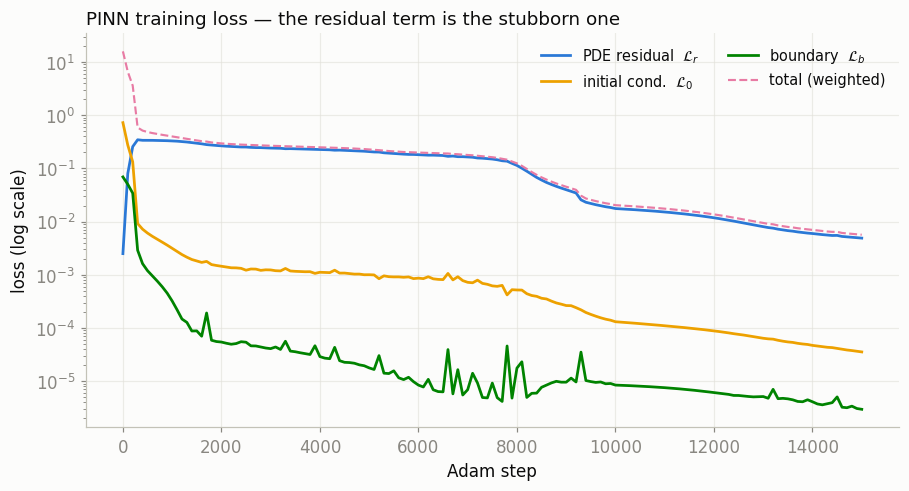

In [7]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.plot(history[:, 0], history[:, 2], color=BLUE,    lw=1.8, label=r"PDE residual  $\mathcal{L}_r$")
ax.plot(history[:, 0], history[:, 3], color=YELLOW,  lw=1.8, label=r"initial cond.  $\mathcal{L}_0$")
ax.plot(history[:, 0], history[:, 4], color=GREEN,   lw=1.8, label=r"boundary  $\mathcal{L}_b$")
ax.plot(history[:, 0], history[:, 1], color=MAGENTA, lw=1.4, ls="--", label="total (weighted)")
ax.set_yscale("log")
ax.set_xlabel("Adam step"); ax.set_ylabel("loss (log scale)")
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.grid(True, alpha=0.6); ax.set_axisbelow(True)
ax.legend(ncol=2, fontsize=9.5)
ax.set_title("PINN training loss — the residual term is the stubborn one", loc="left")
plt.tight_layout(); plt.show()

## 7. The learned solution

Evaluate the trained network on a dense $(x,t)$ grid — a **continuous** solution I can
sample anywhere, no interpolation. The heatmap shows the sine wave steepening into a
shock near $x=0$; the slices confirm the initial condition is matched at $t=0$ and the
front sharpens as $t\to 1$.

initial-condition MSE at t=0: 4.39e-05   |   u range [-0.994, 1.000]


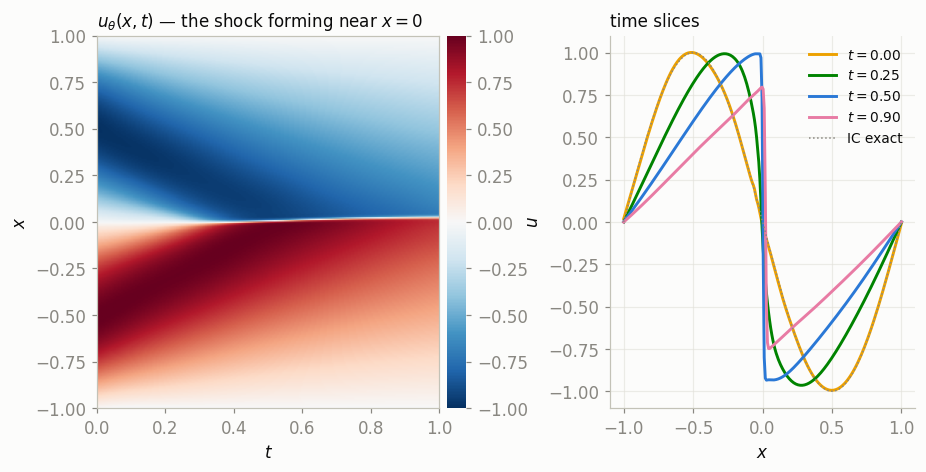

In [8]:
nx, nt = 256, 200
xg = jnp.linspace(-1, 1, nx); tg = jnp.linspace(0, 1, nt)
XX, TT = jnp.meshgrid(xg, tg)
U = np.array(batched_u(params, XX.ravel(), TT.ravel())).reshape(nt, nx)

ic_mse = float(np.mean((U[0] - (-np.sin(np.pi * np.array(xg)))) ** 2))
print(f"initial-condition MSE at t=0: {ic_mse:.2e}   |   u range [{U.min():.3f}, {U.max():.3f}]")

fig = plt.figure(figsize=(9.6, 4.4))
gs = fig.add_gridspec(1, 2, width_ratios=[1.35, 1.0], wspace=0.28)

ax0 = fig.add_subplot(gs[0])
im = ax0.imshow(U.T, origin="lower", aspect="auto", cmap="RdBu_r",
                extent=[0, 1, -1, 1], vmin=-1, vmax=1)
ax0.set_xlabel("$t$"); ax0.set_ylabel("$x$")
ax0.set_title(r"$u_\theta(x, t)$ — the shock forming near $x=0$", loc="left", fontsize=11)
cb = fig.colorbar(im, ax=ax0, pad=0.02); cb.outline.set_visible(False)

ax1 = fig.add_subplot(gs[1])
for tt, c in zip([0.0, 0.25, 0.5, 0.9], [YELLOW, GREEN, BLUE, MAGENTA]):
    j = int(tt * (nt - 1))
    ax1.plot(np.array(xg), U[j], color=c, lw=1.9, label=f"$t={tt:.2f}$")
ax1.plot(np.array(xg), -np.sin(np.pi * np.array(xg)), color=MUTED, lw=1.0, ls=":", label="IC exact")
ax1.set_xlabel("$x$"); ax1.set_ylabel("$u$")
for s in ("top", "right"): ax1.spines[s].set_visible(False)
ax1.grid(True, alpha=0.6); ax1.set_axisbelow(True)
ax1.legend(fontsize=9); ax1.set_title("time slices", loc="left", fontsize=11)
plt.show()

## What this shows, and what it doesn't

- **The physics really was the supervision.** Nothing labeled the interior of the domain;
  the shock emerged purely from driving the PDE residual toward zero at random points plus
  fitting the initial/boundary data.
- **Autodiff did all the differential-operator work** — `u_t`, `u_x`, `u_xx` are exact,
  mesh-free, and evaluable anywhere.
- **Adam alone leaves error on the table.** The residual plateaus around $10^{-3}$. In the
  [optimizer study](../optimizer-study.md) I show that a second-order / self-scaled
  quasi-Newton phase drives the same kind of PINN one to four orders of magnitude lower —
  the front here would get correspondingly sharper.
- **This is a *forward* problem, where a classical solver would still win.** PINNs earn
  their keep on inverse and mesh-free problems; this notebook is about seeing the
  machinery clearly, not beating a finite-difference code.
